<b>PREGUNTA DE NEGOCIO SEMANA 3</b>


<b>¿Hay una relación entre el precio del alojamiento y la satisfacción general de los clientes? ¿Cómo varía esta relación entre las ciudades?</b>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns',  40)

In [5]:
df = pd.read_csv('tourist_accommodation_10112025_clean.csv')
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,is_valid,ocupacion_mes
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,True,7,20,40,130,78.0,2010-02-01,2017-05-09,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.406109,Spain,Málaga,2018-07-31,True,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,Cármenes,Latina,Private room,1,1,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,True,0,0,0,162,33.0,2014-10-10,NaN,92.0,9.0,9.0,10.0,10.0,8.0,9.0,0,0.244444,Spain,Madrid,2020-01-10,True,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2.0,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,True,26,31,31,270,148.0,2011-05-01,NaN,98.0,10.0,10.0,10.0,10.0,10.0,10.0,1,0.836473,Spain,Sevilla,2019-07-29,True,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,True,9,23,49,300,292.0,NaN,2020-04-01,94.0,10.0,9.0,10.0,10.0,10.0,9.0,1,4.273171,Spain,Barcelona,2020-01-10,True,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2.0,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,True,0,19,49,312,36.0,2011-08-07,2018-08-08,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.207294,Spain,Girona,2019-02-19,True,30


## Distribución de rating por precio

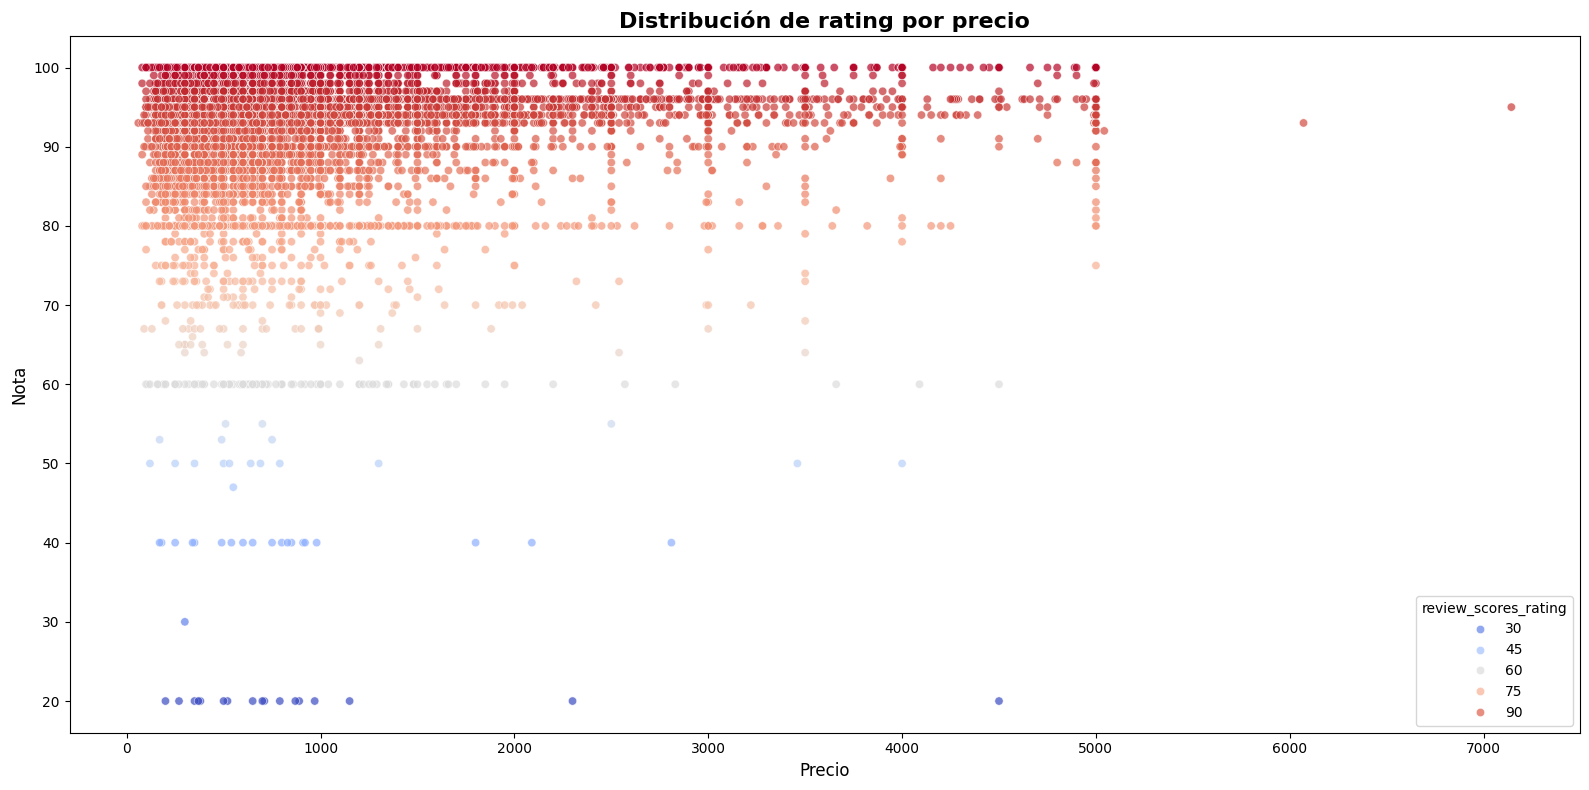

In [6]:
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=df,
    x='price',
    y='review_scores_rating',
    hue='review_scores_rating',
    palette='coolwarm',
    alpha=0.7,
    sizes=(10, 200)
)
plt.title("Distribución de rating por precio", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12)
plt.ylabel("Nota", fontsize=12)
plt.tight_layout()
plt.show()


## Distribución de precios por ciudad

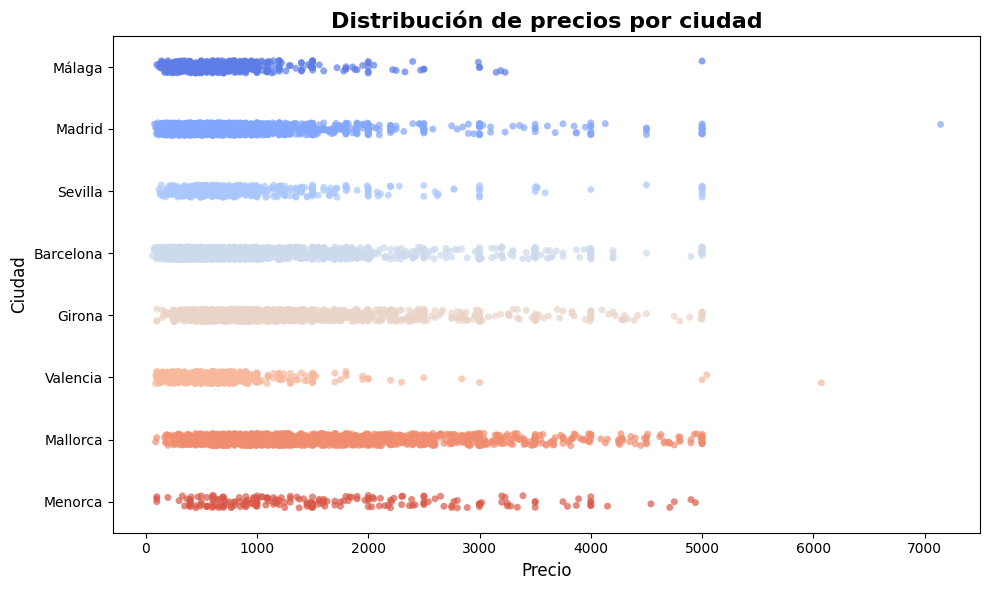

In [7]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df,
    x='price',
    y='city',
    jitter=True,
    alpha=0.7,
    palette='coolwarm'
)
plt.title("Distribución de precios por ciudad", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12),
plt.ylabel("Ciudad", fontsize=12),
plt.tight_layout()
plt.show()

## Distribución de rating por ciudad

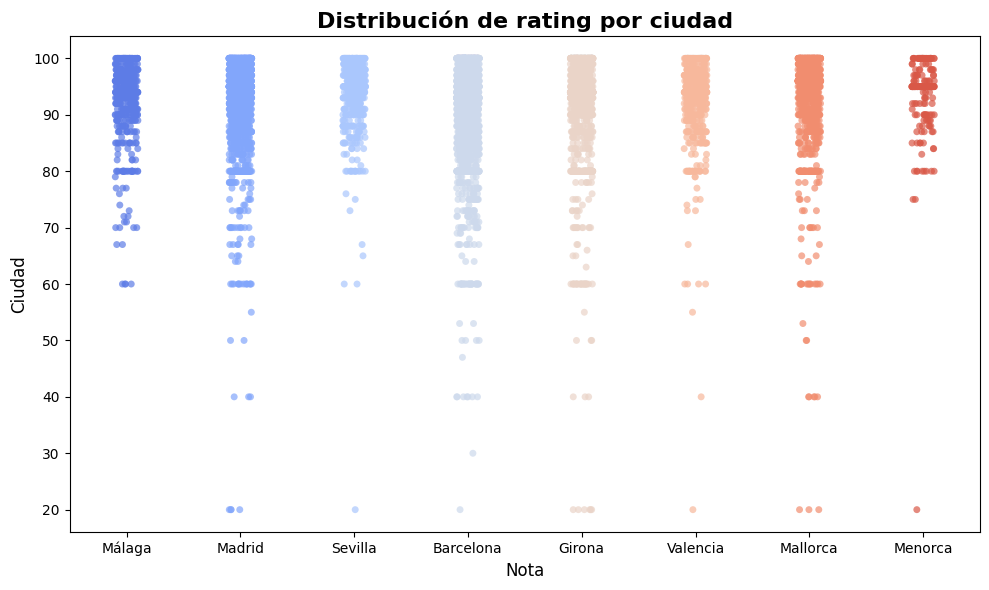

In [8]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df,
    x='city',
    y='review_scores_rating',
    jitter=True,
    alpha=0.7,
    palette='coolwarm'
)
plt.title("Distribución de rating por ciudad", fontsize=16, weight='bold')
plt.xlabel("Nota", fontsize=12),
plt.ylabel("Ciudad", fontsize=12),
plt.tight_layout()
plt.show()

## Correlación precio y satisfacción por ciudad

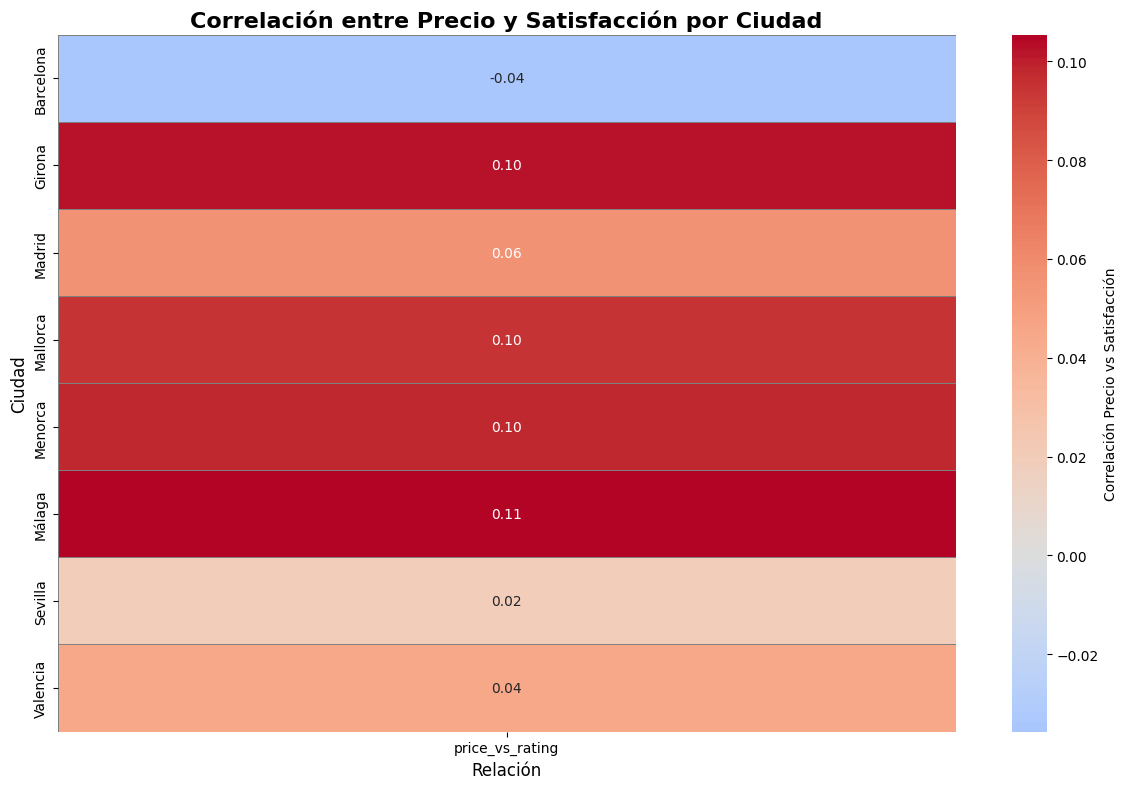

In [9]:
# Filtramos filas con valores nulos
df_corr = df.dropna(subset=['city', 'price', 'review_scores_rating']).copy()

# Creamos un DataFrame para almacenar las correlaciones por ciudad
corr_data = []

for city, g in df_corr.groupby('city'):
    if len(g) > 1:  # Solo calculamos si hay suficientes datos
        corr = g[['price', 'review_scores_rating']].corr().iloc[0,1]  # Correlación entre price y rating
        corr_data.append({'city': city, 'price_vs_rating': corr})

corr_df = pd.DataFrame(corr_data).set_index('city')

# --- 2. Visualización con heatmap ---

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Correlación Precio vs Satisfacción'}
)

plt.title("Correlación entre Precio y Satisfacción por Ciudad", fontsize=16, weight='bold')
plt.xlabel("Relación", fontsize=12)
plt.ylabel("Ciudad", fontsize=12)
plt.tight_layout()
plt.show()


## Métricas por ciudad

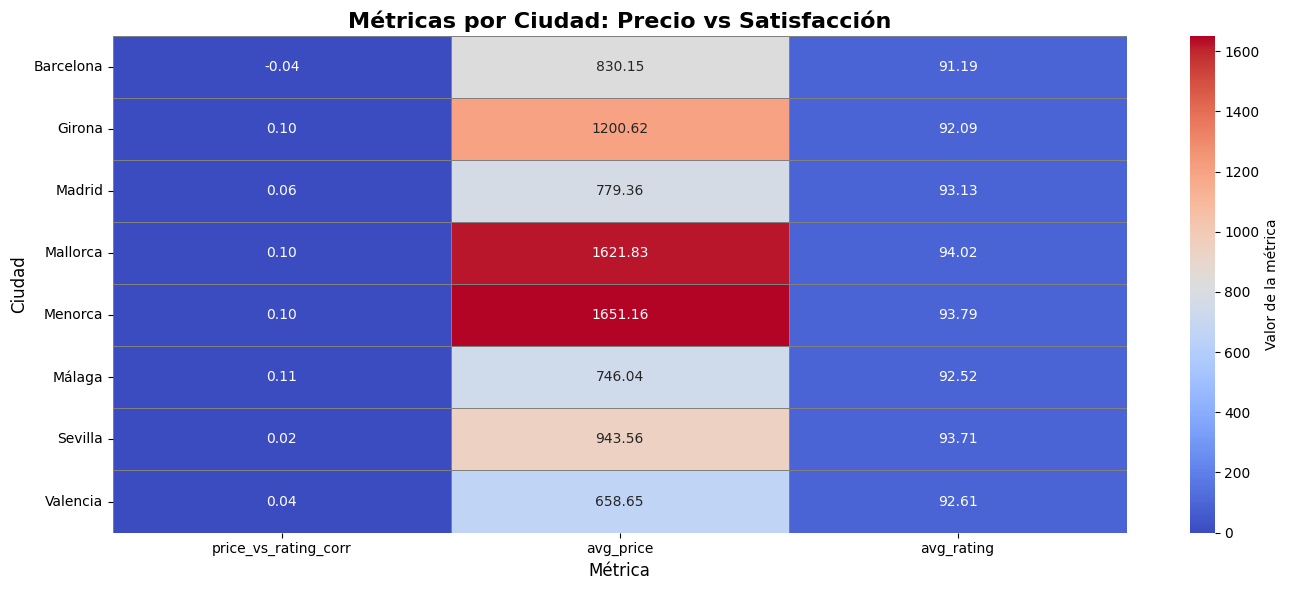

In [10]:
# Filtramos filas con valores nulos
df_filtered = df.dropna(subset=['city', 'price', 'review_scores_rating']).copy()

# --- 2. Creamos DataFrame con métricas por ciudad ---
metrics = []

for city, g in df_filtered.groupby('city'):
    if len(g) > 1:  # mínimo 2 datos para correlación
        corr = g[['price', 'review_scores_rating']].corr().iloc[0,1]
        avg_price = g['price'].mean()
        avg_rating = g['review_scores_rating'].mean()
        count = len(g)
        metrics.append({
            'city': city,
            'price_vs_rating_corr': corr,
            'avg_price': avg_price,
            'avg_rating': avg_rating
        })

metrics_df = pd.DataFrame(metrics).set_index('city')

# --- 3. Heatmap con varias métricas ---
plt.figure(figsize=(14, len(metrics_df)*0.5 + 2))
sns.heatmap(
    metrics_df, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    linewidths=0.5, 
    linecolor='gray',
    cbar_kws={'label': 'Valor de la métrica'}
)

plt.title("Métricas por Ciudad: Precio vs Satisfacción", fontsize=16, weight='bold')
plt.xlabel("Métrica", fontsize=12)
plt.ylabel("Ciudad", fontsize=12)
plt.tight_layout()
plt.show()


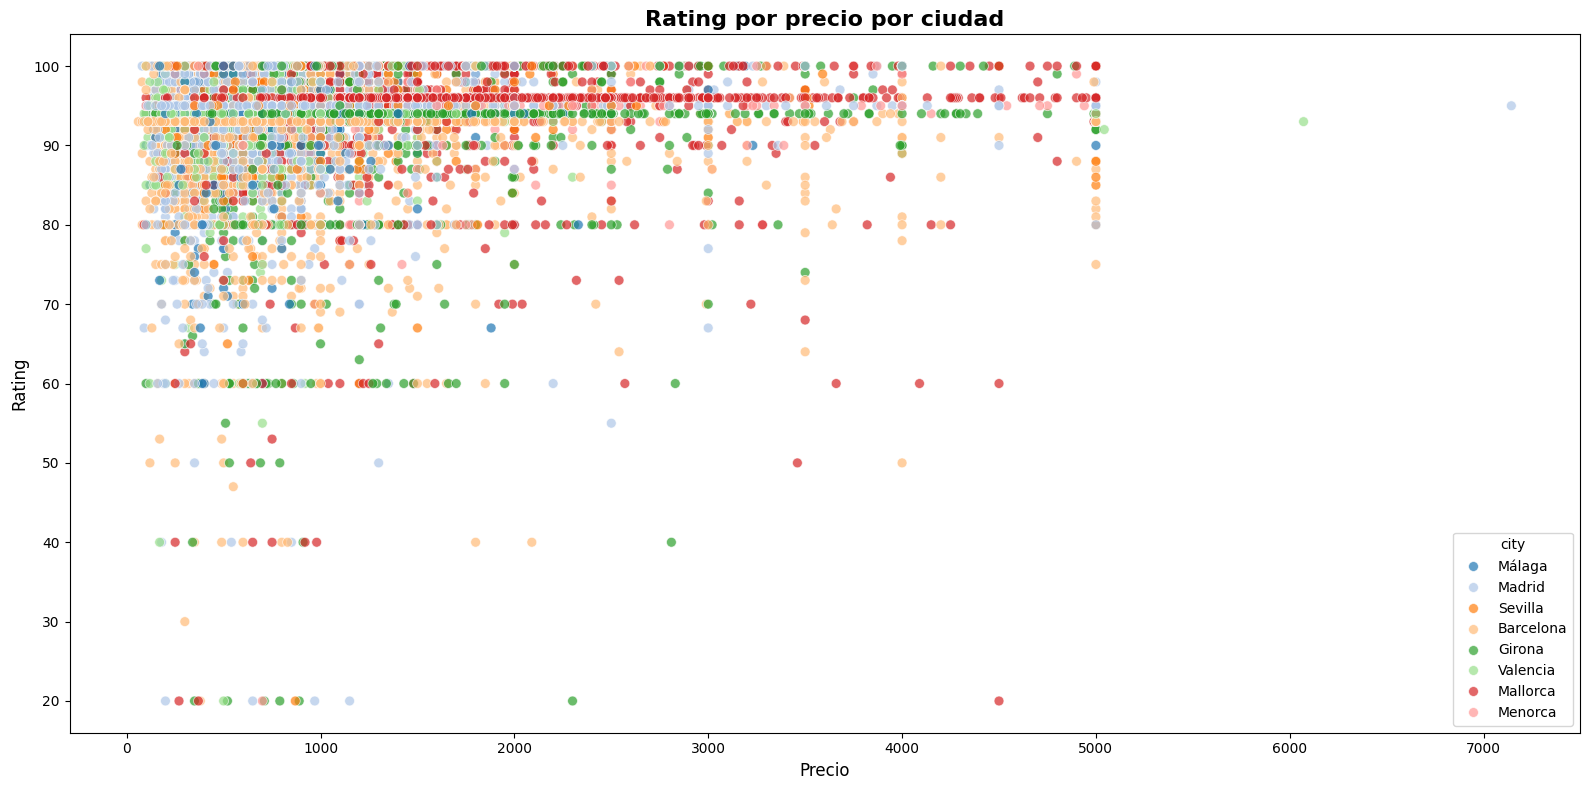

In [11]:
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=df,
    x='price',
    y='review_scores_rating',
    hue='city',     
    alpha=0.7,       # transparencia para ver puntos superpuestos
    palette='tab20', 
    s=50             
)
plt.title("Rating por precio por ciudad", fontsize=16, weight='bold')
plt.xlabel("Precio", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.tight_layout()
plt.show()


## Facetgrid por ciudades

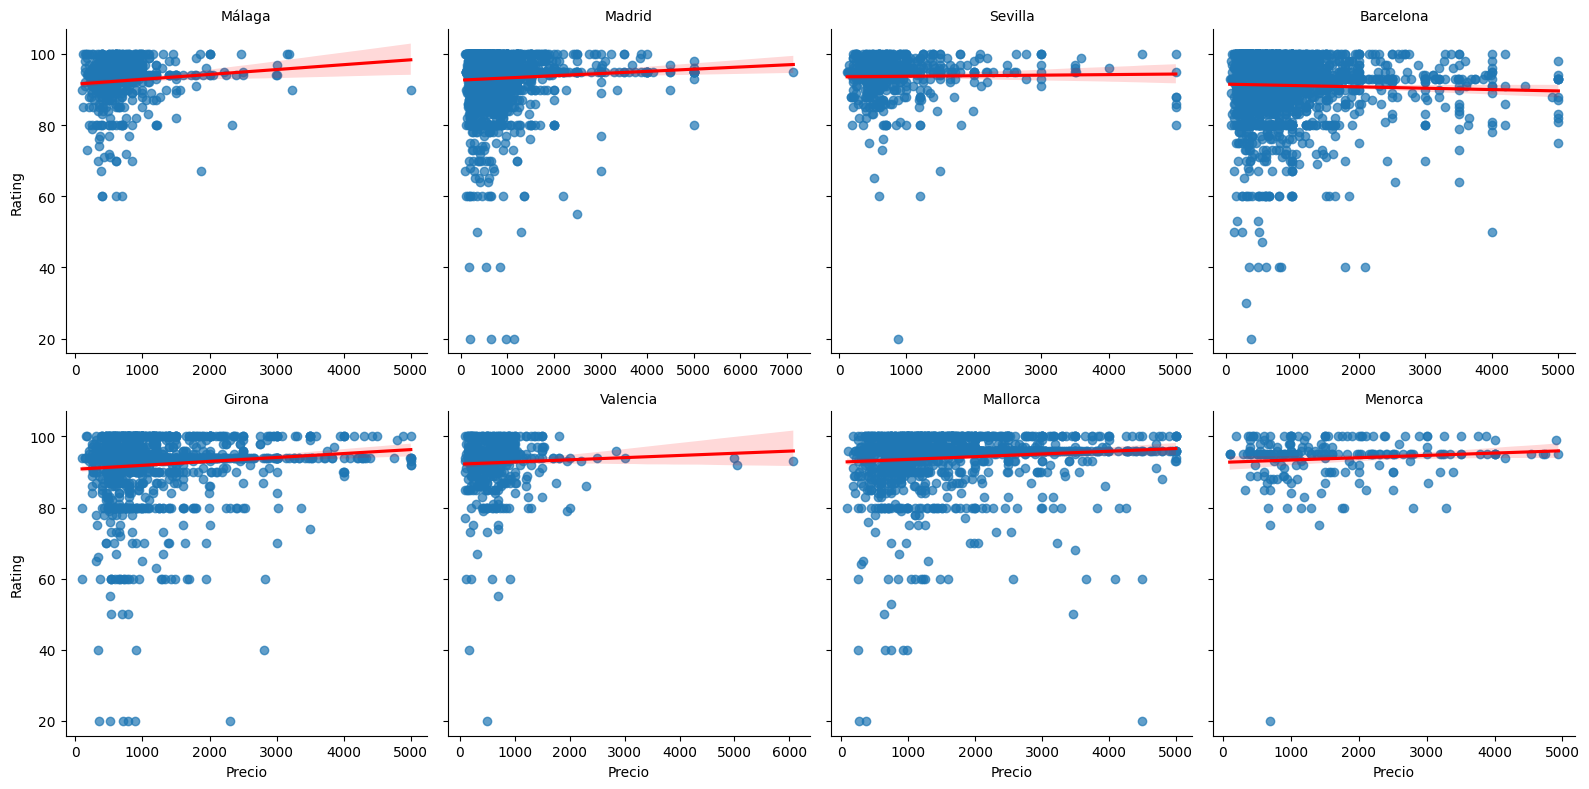

In [12]:
g = sns.FacetGrid(df, col='city', col_wrap=4, height=4, sharex=False, sharey=True)
g.map_dataframe(sns.regplot, x='price', y='review_scores_rating', scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
g.set_axis_labels("Precio", "Rating")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()